# Part 4: Image-to-Sentence Neural Network

## Hypotheses 
| Architecture | Hypothesis |
|---|---|
| SmallCNN | Enough capacity for *shapes* (a small palette of colours and shapes), but will underfit *numbers* (multi-digit recognition needs more receptive field) and *tictactoe* (9-cell spatial reasoning). |
| DeepCNN  | Extra depth + BatchNorm should beat SmallCNN across all three domains, but the larger parameter count risks overfitting on the smaller training set. |
| ResNetTransfer | Pretrained ImageNet features should give the best generalisation despite the domain gap between natural photos and our synthetic renders, because the early-layer filters (edges, colour blobs) still transfer. |

## How to use
Set `DOMAIN` in the config cell to one of `'shapes'`, `'numbers'`, `'tictactoe'`
and run the notebook top-to-bottom. Repeat for each domain.


## 0. Setup

In [2]:
!pip install torch torchvision pandas numpy pillow scikit-learn matplotlib seaborn tqdm

In [4]:
import sys
!{sys.executable} -m pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 18.2 MB/s  0:00:00


In [59]:
import os, json, random, time, math
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split


DOMAIN       = "tictactoe"          # one of: "shapes", "numbers", "tictactoe."
IMG_DIR      = f"generated_images/{DOMAIN}"
CSV_FILE     = f"Part_1_{DOMAIN}.csv"
LABEL_FILE   = f"{DOMAIN}_labels.npy"
RESULTS_DIR  = Path(f"part4_results/{DOMAIN}")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE     = 96                
IMG_SIZE_RES = 224               
BATCH_SIZE   = 64
EPOCHS       = 25
LR           = 1e-3
SEED         = 42
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE == "cuda": torch.cuda.manual_seed_all(SEED)
print("Domain:", DOMAIN)
print("Device:", DEVICE)
print("Results will be saved to:", RESULTS_DIR.resolve())

Domain: tictactoe
Device: cpu
Results will be saved to: /Users/nikunjbhavsar/Desktop/AItextanalysis/part4_results/tictactoe


## 1. Load data and build train / val / test splits


In [60]:
df = pd.read_csv(CSV_FILE)
embeddings = np.load(LABEL_FILE).astype(np.float32)
assert len(df) == len(embeddings), \
    f"Row count mismatch: csv={len(df)} embeddings={len(embeddings)}"
print(f"Loaded {len(df)} rows, embedding dim = {embeddings.shape[1]}")
df.head(3)

Loaded 3419 rows, embedding dim = 384


,sentence_id,template_id,sentence,board_state,x_count,x_positions,o_count,o_positions
0,1,3,"X occupies the top-center, the center, and the...",_|X|_|_|X|O|X|O|_,3,"top-center, center, bottom-left",2,"middle-right, bottom-center"
1,2,2,X has played in the top-right and bottom-right...,_|_|X|_|_|O|O|_|X,2,"top-right, bottom-right",2,"middle-right, bottom-left"
2,3,5,"X marks the bottom-left, the bottom-right, the...",X|O|_|O|O|X|X|_|X,4,"bottom-left, bottom-right, middle-right, top-left",3,"middle-left, top-center, center"


In [61]:
def _img_path(sid: int) -> str:
    return os.path.join(IMG_DIR, f"{int(sid)}.png")

df["img_path"] = df["sentence_id"].map(_img_path)
exists_mask    = df["img_path"].map(os.path.exists)
missing        = (~exists_mask).sum()
if missing:
    print(f"WARNING: {missing} image files are missing — re-run Part 2. "
          f"They will be excluded from this run.")
    keep_idx     = np.where(exists_mask.values)[0]
    df           = df.iloc[keep_idx].reset_index(drop=True)
    embeddings   = embeddings[keep_idx]
print(f"After existence check: {len(df)} usable rows.")

After existence check: 3419 usable rows.


In [62]:
strat = df["template_id"].values if "template_id" in df.columns else None

idx_trainval, idx_test = train_test_split(
    np.arange(len(df)), test_size=0.10, random_state=SEED, stratify=strat)
strat_tv = strat[idx_trainval] if strat is not None else None
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=1/9, random_state=SEED, stratify=strat_tv)   # 1/9 of 90% ≈ 10%

print(f"train={len(idx_train)}  val={len(idx_val)}  test={len(idx_test)}")
np.save(RESULTS_DIR / "split_train.npy", idx_train)
np.save(RESULTS_DIR / "split_val.npy",   idx_val)
np.save(RESULTS_DIR / "split_test.npy",  idx_test)

train=2735  val=342  test=342


## 2. Dataset and DataLoaders


In [63]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class ImageEmbeddingDataset(Dataset):
    """Returns (image_tensor, embedding_tensor, dataframe_index)."""
    def __init__(self, df, embeddings, indices, image_size=96, normalize_imagenet=False):
        self.df          = df
        self.embeddings  = embeddings
        self.indices     = np.asarray(indices)
        tfm = [transforms.Resize((image_size, image_size)), transforms.ToTensor()]
        if normalize_imagenet:
            tfm.append(transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD))
        self.transform = transforms.Compose(tfm)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        di    = int(self.indices[i])
        path  = self.df.iloc[di]["img_path"]
        img   = Image.open(path).convert("RGB")
        img_t = self.transform(img)
        emb   = torch.from_numpy(self.embeddings[di])
        return img_t, emb, di

def make_loaders(image_size, normalize_imagenet, batch_size=BATCH_SIZE):
    common = dict(df=df, embeddings=embeddings,
                  image_size=image_size,
                  normalize_imagenet=normalize_imagenet)
    train_ds = ImageEmbeddingDataset(indices=idx_train, **common)
    val_ds   = ImageEmbeddingDataset(indices=idx_val,   **common)
    test_ds  = ImageEmbeddingDataset(indices=idx_test,  **common)
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0),
            DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0),
            DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0))

## 3. Architectures (the analytic axis)



In [64]:
EMB_DIM = embeddings.shape[1]   

class SmallCNN(nn.Module):
    """Shallow baseline: 3 conv blocks, ~50k params."""
    def __init__(self, emb_dim=EMB_DIM):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 96 -> 48
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 48 -> 24
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 24 -> 12
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(), nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, emb_dim))

    def forward(self, x):
        return torch.tanh(self.head(self.features(x))) * 0.3

class DeepCNN(nn.Module):
    """Deeper CNN with BatchNorm + Dropout, ~500k params."""
    def __init__(self, emb_dim=EMB_DIM, dropout=0.3):
        super().__init__()
        def block(c_in, c_out):
            return nn.Sequential(
                nn.Conv2d(c_in, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(),
                nn.Conv2d(c_out, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(),
                nn.MaxPool2d(2))
        self.features = nn.Sequential(
            block(3, 32),    # 96 -> 48
            block(32, 64),   # 48 -> 24
            block(64, 128),  # 24 -> 12
            block(128, 256), # 12 -> 6
            block(256, 256), # 6  -> 3
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, emb_dim))

    def forward(self, x):
        return torch.tanh(self.head(self.features(x))) * 0.3

class ResNetTransfer(nn.Module):
    """ImageNet-pretrained ResNet-18 backbone + new MLP head."""
    def __init__(self, emb_dim=EMB_DIM, freeze_backbone=False):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        in_feats = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
        self.head = nn.Sequential(
            nn.Linear(in_feats, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, emb_dim))

    def forward(self, x):
        return torch.tanh(self.head(self.backbone(x))) * 0.3

for name, ctor in [("SmallCNN", SmallCNN), ("DeepCNN", DeepCNN),
                   ("ResNetTransfer", ResNetTransfer)]:
    n = sum(p.numel() for p in ctor().parameters() if p.requires_grad)
    print(f"{name:18s} trainable params: {n:,}")

SmallCNN           trainable params: 81,440
DeepCNN            trainable params: 2,519,840
ResNetTransfer     trainable params: 11,406,528


## 4. Training loop



In [65]:
def cosine_loss(pred, target):
    """1 - cosine_similarity, averaged over the batch."""
    return (1.0 - F.cosine_similarity(pred, target, dim=-1)).mean()

@torch.no_grad()
def evaluate_loader(model, loader):
    model.eval()
    sims = []
    for imgs, embs, _ in loader:
        imgs = imgs.to(DEVICE); embs = embs.to(DEVICE)
        pred = model(imgs)
        sims.append(F.cosine_similarity(pred, embs, dim=-1).cpu())
    return torch.cat(sims).mean().item()

def train_model(model, train_loader, val_loader, *, epochs=EPOCHS, lr=LR, name=""):
    model = model.to(DEVICE)
    opt   = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    history = {"train_loss": [], "val_cos": []}
    best_val, best_state = -1.0, None
    t0 = time.time()
    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0; n = 0
        for imgs, embs, _ in train_loader:
            imgs = imgs.to(DEVICE); embs = embs.to(DEVICE)
            opt.zero_grad()
            loss = cosine_loss(model(imgs), embs)
            loss.backward()
            opt.step()
            running += loss.item() * imgs.size(0); n += imgs.size(0)
        sched.step()
        train_loss = running / n
        val_cos    = evaluate_loader(model, val_loader)
        history["train_loss"].append(train_loss)
        history["val_cos"].append(val_cos)
        print(f"  [{name}] epoch {ep:02d}  train_loss={train_loss:.4f}  val_cos={val_cos:.4f}")
        if val_cos > best_val:
            best_val   = val_cos
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(f"  [{name}] best val_cos={best_val:.4f}  total time={time.time()-t0:.1f}s")
    model.load_state_dict(best_state)
    return model, history

## 5. Train each architecture



In [66]:
# Loaders for the from-scratch CNNs 
small_train, small_val, small_test = make_loaders(IMG_SIZE, normalize_imagenet=False)
# Loaders for ResNet 
res_train,   res_val,   res_test   = make_loaders(IMG_SIZE_RES, normalize_imagenet=True)

models_to_train = [
    ("SmallCNN",       SmallCNN(),       small_train, small_val, small_test),
    ("DeepCNN",        DeepCNN(),        small_train, small_val, small_test),
    ("ResNetTransfer", ResNetTransfer(), res_train,   res_val,   res_test),
]

trained = {}    
for name, model, tr, va, te in models_to_train:
    print(f"\n=== Training {name} ===")
    model, hist = train_model(model, tr, va, name=name)
    torch.save(model.state_dict(), RESULTS_DIR / f"{name}.pt")
    trained[name] = (model, hist, te)


=== Training SmallCNN ===
  [SmallCNN] epoch 01  train_loss=0.2431  val_cos=0.9058
  [SmallCNN] epoch 02  train_loss=0.0910  val_cos=0.9106
  [SmallCNN] epoch 03  train_loss=0.0894  val_cos=0.9109
  [SmallCNN] epoch 04  train_loss=0.0895  val_cos=0.9108
  [SmallCNN] epoch 05  train_loss=0.0892  val_cos=0.9110
  [SmallCNN] epoch 06  train_loss=0.0894  val_cos=0.9107
  [SmallCNN] epoch 07  train_loss=0.0894  val_cos=0.9109
  [SmallCNN] epoch 08  train_loss=0.0894  val_cos=0.9109
  [SmallCNN] epoch 09  train_loss=0.0894  val_cos=0.9108
  [SmallCNN] epoch 10  train_loss=0.0892  val_cos=0.9110
  [SmallCNN] epoch 11  train_loss=0.0892  val_cos=0.9110
  [SmallCNN] epoch 12  train_loss=0.0890  val_cos=0.9110
  [SmallCNN] epoch 13  train_loss=0.0887  val_cos=0.9116
  [SmallCNN] epoch 14  train_loss=0.0876  val_cos=0.9133
  [SmallCNN] epoch 15  train_loss=0.0850  val_cos=0.9159
  [SmallCNN] epoch 16  train_loss=0.0824  val_cos=0.9172
  [SmallCNN] epoch 17  train_loss=0.0812  val_cos=0.9175
  [S

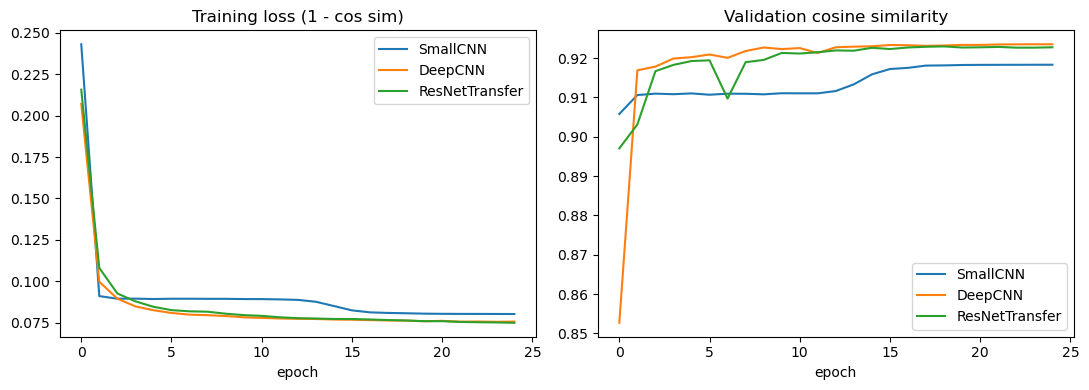

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, (_, hist, _) in trained.items():
    axes[0].plot(hist["train_loss"], label=name)
    axes[1].plot(hist["val_cos"],    label=name)
axes[0].set_title("Training loss (1 - cos sim)"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].set_title("Validation cosine similarity"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=150)
plt.show()

## 6. Evaluation on the held-out test set



In [68]:
DOMAIN_FIELDS = {
    "shapes":    ["obj1_shape", "obj1_colour", "obj1_size",
                  "relation",
                  "obj2_shape", "obj2_colour", "obj2_size"],
    "numbers":   ["number", "colour", "size"],
    "tictactoe": ["board_state"],
}
FIELDS = DOMAIN_FIELDS[DOMAIN]
print("Fields:", FIELDS)

Fields: ['board_state']


In [69]:
@torch.no_grad()
def predict_embeddings(model, loader):
    """Return (predicted_embeddings, dataframe_indices) for an entire loader."""
    model.eval()
    preds, idxs = [], []
    for imgs, _, di in loader:
        preds.append(model(imgs.to(DEVICE)).cpu().numpy())
        idxs.append(np.asarray(di))
    return np.concatenate(preds), np.concatenate(idxs)

def cosine_matrix(A, B):
    """Pairwise cosine similarity (rows of A vs rows of B)."""
    A = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-12)
    B = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-12)
    return A @ B.T

def evaluate_predictions(pred_emb, query_idx, fields):
    """
    Compute mean cosine sim, top-k retrieval accuracy, per-field accuracy.

    Candidate pool = all *unique* sentences in the test split (we use the true
    MiniLM embeddings as the pool, not the model predictions).
    """
    true_emb = embeddings[query_idx]
    cos_sim  = (pred_emb / (np.linalg.norm(pred_emb, axis=1, keepdims=True) + 1e-12)
              * true_emb / (np.linalg.norm(true_emb, axis=1, keepdims=True) + 1e-12)).sum(axis=1)
    mean_cos = float(cos_sim.mean())

    test_df            = df.iloc[query_idx].copy().reset_index(drop=True)
    test_df["_qpos"]   = np.arange(len(test_df))                 # row in pred_emb
    pool               = test_df.drop_duplicates("sentence").reset_index(drop=True)
    pool_idx_in_df     = pool.index.values                       # rows in pool
    pool_emb           = embeddings[query_idx[pool_idx_in_df]]   # MiniLM targets

    sim = cosine_matrix(pred_emb, pool_emb)                      
    rank_order = np.argsort(-sim, axis=1)                        

    sentence_to_pool = {s: i for i, s in enumerate(pool["sentence"].values)}
    correct_pool_idx = test_df["sentence"].map(sentence_to_pool).values

    topk = {}
    for k in (1, 5, 10):
        hits = (rank_order[:, :k] == correct_pool_idx[:, None]).any(axis=1)
        topk[f"top{k}"] = float(hits.mean())

    top1_pool_idx       = rank_order[:, 0]
    retrieved_df_idx    = query_idx[pool_idx_in_df[top1_pool_idx]]
    retrieved_rows      = df.iloc[retrieved_df_idx].reset_index(drop=True)
    true_rows           = test_df

    field_acc, mismatches = {}, {}
    for f in fields:
        eq = (retrieved_rows[f].astype(str).str.strip().str.lower()
              == true_rows[f].astype(str).str.strip().str.lower())
        field_acc[f]  = float(eq.mean())
        mismatches[f] = (~eq).values


    if len(fields):
        all_correct = np.ones(len(true_rows), dtype=bool)
        for f in fields:
            all_correct &= ~mismatches[f]
        field_acc["all_fields"] = float(all_correct.mean())

    return {
        "mean_cosine":  mean_cos,
        "topk":         topk,
        "field_acc":    field_acc,
        "cos_sim_per_sample": cos_sim,
        "rank_order":   rank_order,
        "pool":         pool,
        "test_df":      test_df,
        "query_idx":    np.asarray(query_idx),     
        "retrieved_df_idx": retrieved_df_idx,
    }

In [70]:
results = {}
for name, (model, hist, te) in trained.items():
    pred, idxs = predict_embeddings(model, te)
    results[name] = evaluate_predictions(pred, idxs, FIELDS)

rows = []
for name, r in results.items():
    row = {"model": name,
           "mean_cosine": r["mean_cosine"],
           **{k: v for k, v in r["topk"].items()},
           **{f"field_{k}": v for k, v in r["field_acc"].items()}}
    rows.append(row)
summary = pd.DataFrame(rows).set_index("model")
summary.to_csv(RESULTS_DIR / "summary.csv")
print(summary.round(4).to_string())

                mean_cosine    top1    top5   top10  field_board_state  field_all_fields
model                                                                                   
SmallCNN             0.9201  0.0117  0.0468  0.0848             0.0175            0.0175
DeepCNN              0.9249  0.0263  0.1140  0.1696             0.0322            0.0322
ResNetTransfer       0.9243  0.0234  0.1111  0.1491             0.0292            0.0292


## 7. Random baselines and headline plot

We compute trivial baselines so the headline numbers are interpretable: a
random vector for cosine, and `k / |pool|` for top-k retrieval.

In [71]:
def random_baselines(query_idx, fields, n_trials=200):
    rng = np.random.default_rng(SEED)
    test_df = df.iloc[query_idx].reset_index(drop=True)
    pool    = test_df.drop_duplicates("sentence").reset_index(drop=True)
    n_pool  = len(pool)

    rand   = rng.standard_normal((n_trials, embeddings.shape[1]))
    rand  /= np.linalg.norm(rand, axis=1, keepdims=True)
    true   = embeddings[query_idx]
    true_n = true / (np.linalg.norm(true, axis=1, keepdims=True) + 1e-12)
    sims   = rand @ true_n.T
    rand_cos = float(sims.mean())

    rand_topk = {f"top{k}": k / n_pool for k in (1, 5, 10)}

    rand_field = {}
    for f in fields:
        pool_vals  = pool[f].astype(str).str.strip().str.lower().values
        true_vals  = test_df[f].astype(str).str.strip().str.lower().values
        guesses    = rng.choice(pool_vals, size=(n_trials, len(true_vals)))
        rand_field[f] = float((guesses == true_vals[None, :]).mean())
    return {"mean_cosine": rand_cos, "topk": rand_topk, "field_acc": rand_field}

any_test_loader = next(iter(trained.values()))[2]
baseline = random_baselines(np.asarray(any_test_loader.dataset.indices), FIELDS)
print("Random baselines:")
print(json.dumps(baseline, indent=2, default=float))

Random baselines:
{
  "mean_cosine": -0.001361023639265793,
  "topk": {
    "top1": 0.0029239766081871343,
    "top5": 0.014619883040935672,
    "top10": 0.029239766081871343
  },
  "field_acc": {
    "board_state": 0.003713450292397661
  }
}


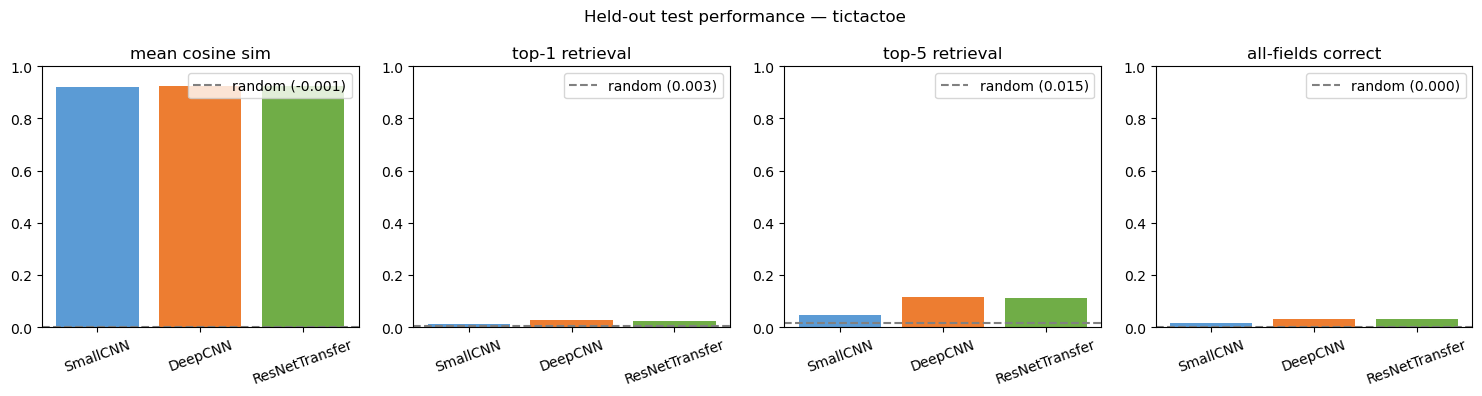

In [72]:
metrics_to_plot = [("mean_cosine",   "mean cosine sim"),
                   ("top1",          "top-1 retrieval"),
                   ("top5",          "top-5 retrieval"),
                   ("all_fields",    "all-fields correct")]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(15, 4))
for ax, (key, title) in zip(axes, metrics_to_plot):
    vals, names = [], []
    for name, r in results.items():
        if key == "mean_cosine":   vals.append(r["mean_cosine"])
        elif key.startswith("top"): vals.append(r["topk"][key])
        else:                       vals.append(r["field_acc"].get(key, np.nan))
        names.append(name)
    ax.bar(names, vals, color=["#5b9bd5", "#ed7d31", "#70ad47"])
    if key == "mean_cosine":   base = baseline["mean_cosine"]
    elif key.startswith("top"): base = baseline["topk"][key]
    else:                       base = baseline["field_acc"].get(key, 0)
    ax.axhline(base, ls="--", color="grey", label=f"random ({base:.3f})")
    ax.set_title(title); ax.legend(); ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=20)
plt.suptitle(f"Held-out test performance — {DOMAIN}")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "headline_metrics.png", dpi=150)
plt.show()

## 8. Error analysis

We break down the test errors along three axes:

1. **Per-field accuracy bar chart** — which structured field is hardest?
2. **Per-template accuracy** — does the model do better on some sentence
   templates than others?
3. **Confusion patterns** — for the most-confused field, plot a confusion
   matrix to identify the specific failure modes (e.g. "purple → blue" for
   numbers, or "above → below" for shapes).
4. **Worked examples** — show a handful of correct and incorrect predictions
   so the report can include qualitative evidence.

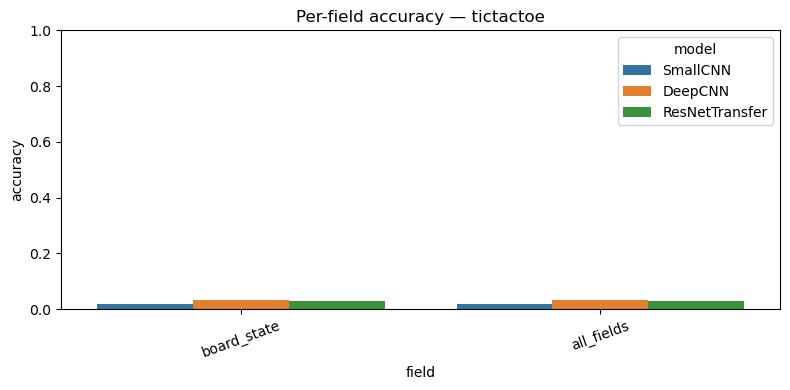

In [73]:
field_rows = []
for name, r in results.items():
    for f, v in r["field_acc"].items():
        field_rows.append({"model": name, "field": f, "accuracy": v})
field_df = pd.DataFrame(field_rows)

plt.figure(figsize=(max(8, 1.2 * len(FIELDS) + 2), 4))
sns.barplot(data=field_df, x="field", y="accuracy", hue="model")
plt.title(f"Per-field accuracy — {DOMAIN}")
plt.ylim(0, 1); plt.xticks(rotation=20); plt.tight_layout()
plt.savefig(RESULTS_DIR / "per_field_accuracy.png", dpi=150)
plt.show()

Best model by top-1: DeepCNN

Top-1 accuracy by template_id:
             top1_acc  count
template_id                 
1               0.069     72
2               0.000     67
3               0.000     71
4               0.059     68
5               0.000     64


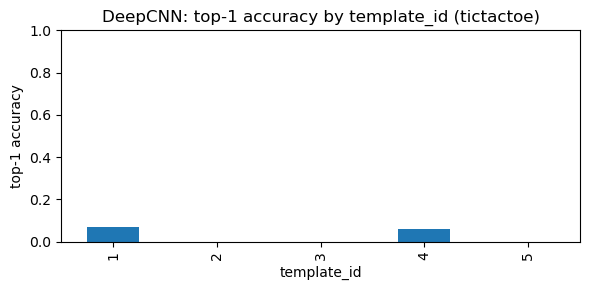

In [74]:
best_model_name = summary["top1"].idxmax()
print("Best model by top-1:", best_model_name)
r = results[best_model_name]

test_df_local = r["test_df"].copy()
rank_order    = r["rank_order"]
top1_correct  = (rank_order[:, 0] == r["test_df"]["sentence"].map(
    {s: i for i, s in enumerate(r["pool"]["sentence"].values)}).values)
test_df_local["correct_top1"] = top1_correct

if "template_id" in test_df_local.columns:
    by_tpl = (test_df_local.groupby("template_id")["correct_top1"]
              .agg(["mean", "count"]).rename(columns={"mean": "top1_acc"}))
    print("\nTop-1 accuracy by template_id:")
    print(by_tpl.round(3).to_string())
    plt.figure(figsize=(6, 3))
    by_tpl["top1_acc"].plot(kind="bar")
    plt.title(f"{best_model_name}: top-1 accuracy by template_id ({DOMAIN})")
    plt.ylim(0, 1); plt.ylabel("top-1 accuracy"); plt.tight_layout()
    plt.savefig(RESULTS_DIR / "per_template_accuracy.png", dpi=150)
    plt.show()

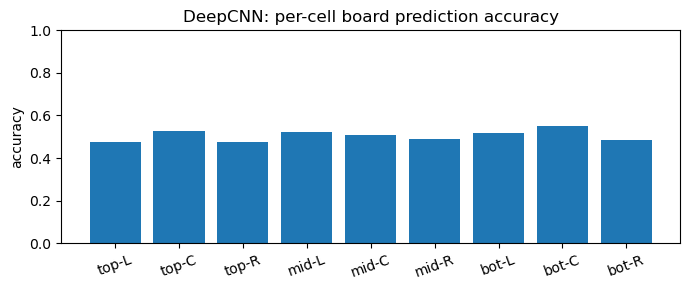

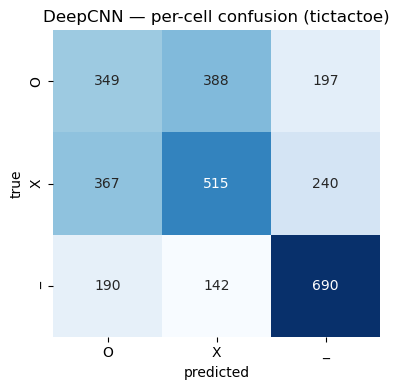

In [75]:
def plot_confusion(true_vals, pred_vals, title, save):
    cats   = sorted(set(true_vals) | set(pred_vals))
    cat_ix = {c: i for i, c in enumerate(cats)}
    M      = np.zeros((len(cats), len(cats)), dtype=int)
    for t, p in zip(true_vals, pred_vals):
        M[cat_ix[t], cat_ix[p]] += 1
    plt.figure(figsize=(max(4, 0.6 * len(cats) + 1.5), max(4, 0.6 * len(cats) + 1)))
    sns.heatmap(M, xticklabels=cats, yticklabels=cats,
                annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("predicted"); plt.ylabel("true"); plt.title(title)
    plt.tight_layout(); plt.savefig(save, dpi=150); plt.show()

retrieved_df_idx = results[best_model_name]["retrieved_df_idx"]
retrieved_rows   = df.iloc[retrieved_df_idx].reset_index(drop=True)
true_rows        = results[best_model_name]["test_df"]

if DOMAIN == "shapes":
    for f in ["obj1_colour", "obj1_shape", "relation"]:
        plot_confusion(true_rows[f].astype(str).str.lower().values,
                       retrieved_rows[f].astype(str).str.lower().values,
                       f"{best_model_name} — confusion on {f} ({DOMAIN})",
                       RESULTS_DIR / f"confusion_{f}.png")
elif DOMAIN == "numbers":
    plot_confusion(true_rows["colour"].astype(str).str.lower().values,
                   retrieved_rows["colour"].astype(str).str.lower().values,
                   f"{best_model_name} — confusion on colour ({DOMAIN})",
                   RESULTS_DIR / "confusion_colour.png")
    if "num_digits" in true_rows.columns:
        nd = true_rows["num_digits"].values
        per_nd = pd.DataFrame({
            "num_digits": nd,
            "number_correct": (true_rows["number"].astype(str).values
                               == retrieved_rows["number"].astype(str).values).astype(int),
        }).groupby("num_digits")["number_correct"].agg(["mean", "count"])
        print("\nNumber-prediction accuracy by digit length:")
        print(per_nd.round(3).to_string())
        plt.figure(figsize=(5, 3))
        per_nd["mean"].plot(kind="bar")
        plt.title(f"{best_model_name}: number accuracy vs digit length")
        plt.ylim(0, 1); plt.ylabel("exact-match acc"); plt.tight_layout()
        plt.savefig(RESULTS_DIR / "number_acc_by_digits.png", dpi=150)
        plt.show()
elif DOMAIN == "tictactoe":
    def cells(s): return s.split("|")
    true_cells = np.array([cells(s) for s in true_rows["board_state"].values])
    pred_cells = np.array([cells(s) for s in retrieved_rows["board_state"].values])
    cell_acc = (true_cells == pred_cells).mean(axis=0)
    pos_names = ["top-L","top-C","top-R","mid-L","mid-C","mid-R","bot-L","bot-C","bot-R"]
    plt.figure(figsize=(7, 3))
    plt.bar(pos_names, cell_acc); plt.ylim(0, 1)
    plt.title(f"{best_model_name}: per-cell board prediction accuracy")
    plt.ylabel("accuracy"); plt.xticks(rotation=20); plt.tight_layout()
    plt.savefig(RESULTS_DIR / "tictactoe_cell_accuracy.png", dpi=150)
    plt.show()
    plot_confusion(true_cells.flatten(), pred_cells.flatten(),
                   f"{best_model_name} — per-cell confusion ({DOMAIN})",
                   RESULTS_DIR / "tictactoe_cell_confusion.png")

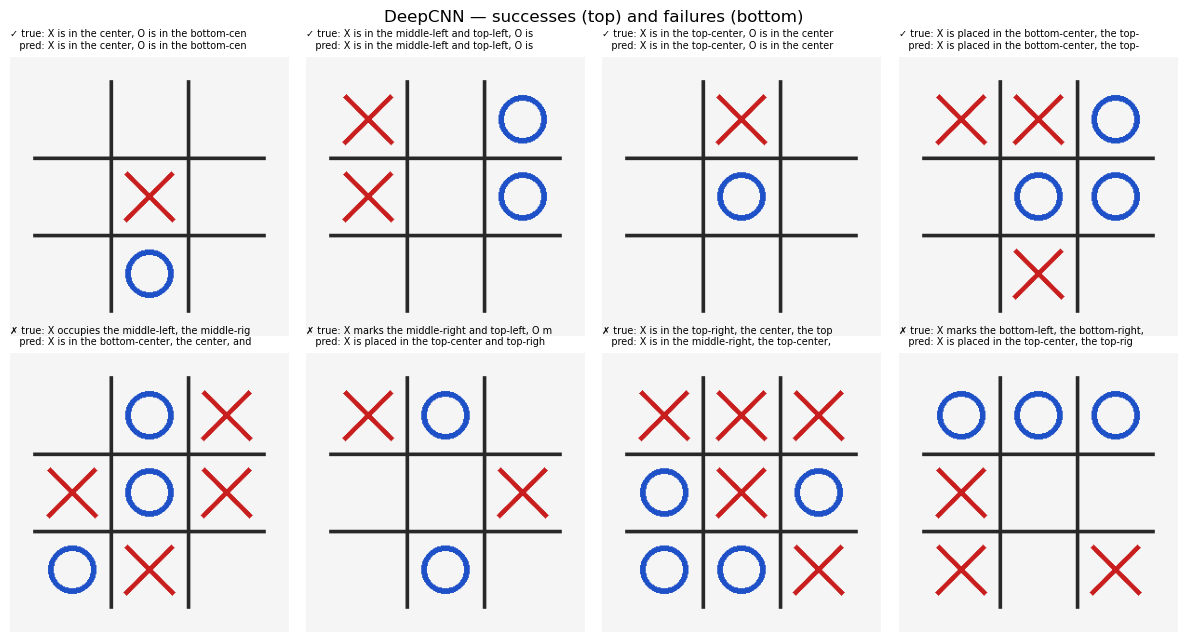

In [76]:
def show_examples(name, n_each=4):
    r = results[name]
    sentence_to_pool = {s: i for i, s in enumerate(r["pool"]["sentence"].values)}
    correct_pool_idx = r["test_df"]["sentence"].map(sentence_to_pool).values
    top1            = r["rank_order"][:, 0]
    correct         = top1 == correct_pool_idx

    rng    = np.random.default_rng(SEED)
    succ   = rng.choice(np.where(correct)[0],  size=min(n_each, correct.sum()),     replace=False) \
             if correct.any()  else np.array([], int)
    fail   = rng.choice(np.where(~correct)[0], size=min(n_each, (~correct).sum()),  replace=False) \
             if (~correct).any() else np.array([], int)

    fig, axes = plt.subplots(2, n_each, figsize=(3 * n_each, 6.5))
    for ax_row, group, label in [(axes[0], succ, "✓"), (axes[1], fail, "✗")]:
        for ax, qi in zip(ax_row, group):
            di      = int(r["query_idx"][qi])           
            true_s  = r["test_df"].iloc[qi]["sentence"]
            pool_i  = top1[qi]
            pred_s  = r["pool"].iloc[pool_i]["sentence"]
            img     = Image.open(df.iloc[di]["img_path"])
            ax.imshow(img); ax.axis("off")
            ax.set_title(f"{label} true: {true_s[:42]}\n   pred: {pred_s[:42]}",
                         fontsize=7, loc="left")
        for ax in ax_row[len(group):]: ax.axis("off")
    plt.suptitle(f"{name} — successes (top) and failures (bottom)")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"examples_{name}.png", dpi=150)
    plt.show()

show_examples(best_model_name)

## 9. Save predictions for downstream comparison

We persist the predicted embeddings + ground truth so that **Part 5** (LLM
comparison) can plug into the same metric / candidate pool without retraining.

In [78]:
for name, (model, _, te) in trained.items():
    pred, idxs = predict_embeddings(model, te)
    np.savez(RESULTS_DIR / f"predictions_{name}.npz",
             predicted_embeddings=pred,
             dataframe_indices=idxs)
print("Saved predictions for:", list(trained.keys()))
print("\nPart 4 finished.")

Saved predictions for: ['SmallCNN', 'DeepCNN', 'ResNetTransfer']

Part 4 finished.
